In [1]:
# Imports and reproducibility
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(x_train_k, y_train_k), (x_test_k, y_test_k) = fashion_mnist.load_data()

print("Keras load shapes:", x_train_k.shape, y_train_k.shape, x_test_k.shape, y_test_k.shape)

    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

16384/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/26421880 ━━━━━━━━━━━━━━━━━━━━ 2:54 7us/step

...

3399680/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

3858432/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4415488/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Keras load shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [3]:
notebook_dir = Path.cwd()
archive_path = notebook_dir / "fashion_mnist_local.npz"

np.savez_compressed(
    archive_path,
    x_train=x_train_k,
    y_train=y_train_k,
    x_test=x_test_k,
    y_test=y_test_k,
)

print("Saved local bundle (overwrite each run is fine):", archive_path)

Saved local bundle (overwrite each run is fine): C:\Users\sahil\OneDrive\Desktop\CODE\Projects\LP-V\DL\7.Fashion_MNIST_CNN\fashion_mnist_local.npz


In [4]:
if not archive_path.is_file():
    raise FileNotFoundError(
        "Run the previous cells once so Keras can fill fashion_mnist_local.npz, "
        "or copy that archive from another machine next to this notebook."
    )

bundle = np.load(archive_path)
x_train = bundle["x_train"]
y_train = bundle["y_train"]
x_test = bundle["x_test"]
y_test = bundle["y_test"]

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("Local load shapes:", x_train.shape, y_train.shape)

Local load shapes: (60000, 28, 28) (60000,)


In [5]:
# Scale pixels to 0–1 and add channel dimension for Conv2D
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

num_classes = len(class_names)
input_shape = x_train.shape[1:]

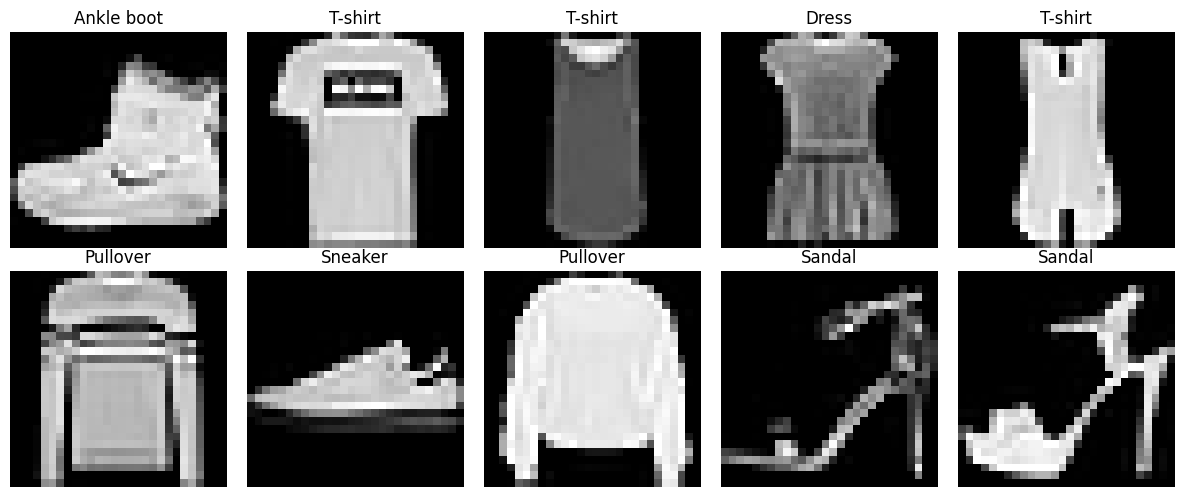

In [6]:
# Visual sanity check
figure, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for index in range(10):
    axes[index].imshow(x_train[index].squeeze(), cmap="gray")
    label_index = int(y_train[index])
    axes[index].set_title(class_names[label_index])
    axes[index].axis("off")
plt.tight_layout()
plt.show()

In [7]:
# CNN architecture
model = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train
epochs = 10
batch_size = 128

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/10


  1/422 ━━━━━━━━━━━━━━━━━━━━ 11:57 2s/step - accuracy: 0.1094 - loss: 2.2873

  2/422 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.1230 - loss: 2.2647

  3/422 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - accuracy: 0.1471 - loss: 2.2406

  4/422 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - accuracy: 0.1694 - loss: 2.2188

...

419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9432 - loss: 0.1560

420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9432 - loss: 0.1560

421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9432 - loss: 0.1560

422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9432 - loss: 0.1560

422/422 ━━━━━━━━━━━━━━━━━━━━ 62s 147ms/step - accuracy: 0.9423 - loss: 0.1568 - val_accuracy: 0.9190 - val_loss: 0.2245


In [9]:
# Evaluate on held-out test images
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", round(float(test_accuracy), 4))

Test accuracy: 0.916


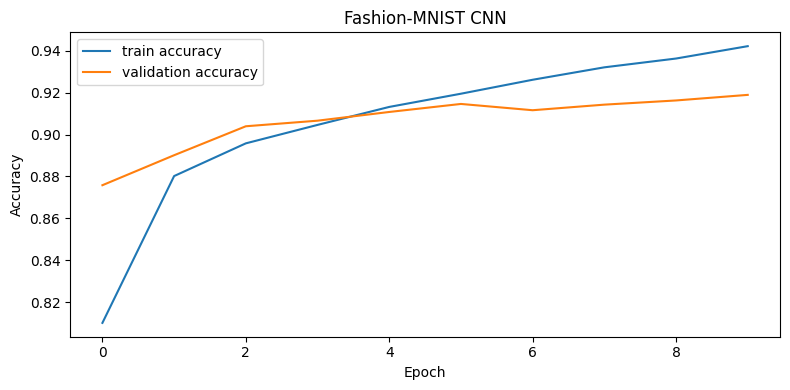

In [10]:
# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Fashion-MNIST CNN")
plt.tight_layout()
plt.show()